In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.spatial.distance import cdist
from scipy.interpolate import splprep, splev
import pandas as pd
from networkx.algorithms.simple_paths import shortest_simple_paths
from itertools import islice

In [4]:
point_df_GA = pd.read_csv('GRAMFEATURE_match_df.csv')
point_df_PA =pd.read_csv('PHOIBLE_z_score_df.csv')

# Real Data 
### Phoneme and Grammar Analysis

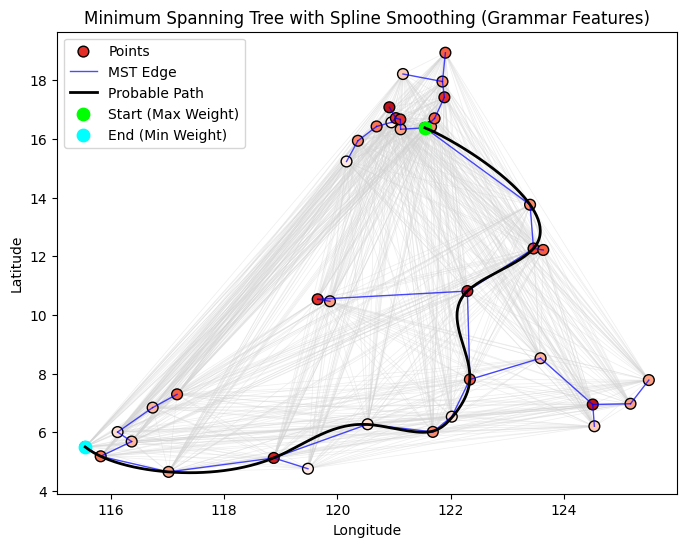

In [41]:
x = point_df_GA['longitude'].values
y = point_df_GA['latitude'].values
weights = point_df_GA['match_score_span'].values
coords = np.column_stack((x, y))

# -----------------------------
# 1. Build Weighted Graph
# -----------------------------
# Edge cost = distance / combined weight
dist_matrix = cdist(coords, coords)
weight_matrix = (weights[:,None] + weights[None,:]) / 2
cost_matrix = dist_matrix/(weight_matrix**2 + 1e-6)  # avoid div0

G = nx.Graph()
for i in range(len(coords)):
    for j in range(i+1, len(coords)):
        G.add_edge(i, j, weight=cost_matrix[i,j])

# -----------------------------
# 2. Minimum Spanning Tree
# -----------------------------
mst = nx.minimum_spanning_tree(G)

# Determine start (max weight) and end (min weight)
start = np.argmax(weights)
end = np.argmin(weights)

# Compute path along MST
path_nodes = nx.shortest_path(mst, source=start, target=end, weight='weight')
path_coords = coords[path_nodes]

# -----------------------------
# 3. Smooth Path with Spline
# -----------------------------
if len(path_coords) > 3:
    tck, u = splprep([path_coords[:,0], path_coords[:,1]], s=0.001)
    u_fine = np.linspace(0,1,300)
    smooth_path = np.array(splev(u_fine, tck)).T
else:
    smooth_path = path_coords

# -----------------------------
# 4. Visualization
# -----------------------------
plt.figure(figsize=(8,6))
plt.scatter(x, y, c=weights, cmap='Reds', edgecolor='k', s=60, label='Points')

for i in range(len(coords)):
    for j in range(i+1, len(coords)):
        plt.plot([coords[i,0], coords[j,0]], [coords[i,1], coords[j,1]], color='lightgray', lw=0.5, alpha=0.4, zorder=0)

for u, v in mst.edges():
    plt.plot([coords[u,0], coords[v,0]], [coords[u,1], coords[v,1]], color='blue', lw=1, alpha=0.7, zorder=1, label='MST Edge' if u == list(mst.edges())[0][0] and v == list(mst.edges())[0][1] else "")

plt.plot(smooth_path[:,0], smooth_path[:,1], 'black', lw=2, label='Probable Path')
plt.scatter(x[start], y[start], c='lime', s=80, label='Start (Max Weight)')
plt.scatter(x[end], y[end], c='cyan', s=80, label='End (Min Weight)')
plt.legend()
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Minimum Spanning Tree with Spline Smoothing (Grammar Features)')
plt.show()

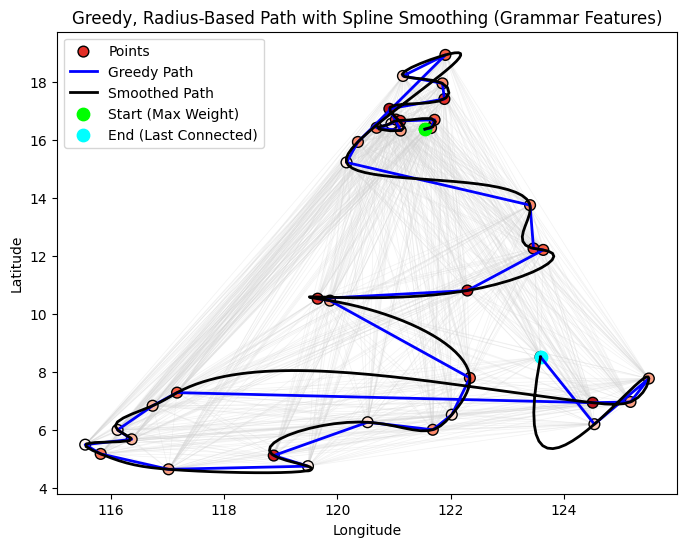

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from scipy.interpolate import splprep, splev

# --- Parameters ---
radius = 3

# --- Data ---
x = point_df_GA['longitude'].values
y = point_df_GA['latitude'].values
weights = point_df_GA['match_score_span'].values
coords = np.column_stack((x, y))

# --- Cost Matrix ---
dist_matrix = cdist(coords, coords)
weight_matrix = (weights[:, None] + weights[None, :]) / 2
alpha = 2  # Increase to make weights more influential
cost_matrix = dist_matrix / (weight_matrix ** alpha + 1e-6)

# --- Greedy Path Construction ---
n_points = len(coords)
visited = np.zeros(n_points, dtype=bool)
path = []

# Start at max weight
current = np.argmax(weights)
path.append(current)
visited[current] = True

while not np.all(visited):
    # Find unvisited neighbors within radius
    dists = dist_matrix[current]
    candidates = np.where((dists <= radius) & (~visited))[0]
    if len(candidates) == 0:
        # If no unvisited neighbors in radius, expand search to all unvisited
        candidates = np.where(~visited)[0]
        if len(candidates) == 0:
            break
    # Choose the candidate with minimum cost
    costs = cost_matrix[current, candidates]
    next_idx = candidates[np.argmin(costs)]
    path.append(next_idx)
    visited[next_idx] = True
    current = next_idx

path_coords = coords[path]

# --- Spline Smoothing ---
if len(path_coords) > 3:
    tck, u = splprep([path_coords[:,0], path_coords[:,1]], s=0.001)
    u_fine = np.linspace(0,1,300)
    smooth_path = np.array(splev(u_fine, tck)).T
else:
    smooth_path = path_coords

# --- Visualization ---
plt.figure(figsize=(8,6))
plt.scatter(x, y, c=weights, cmap='Reds', edgecolor='k', s=60, label='Points')

# Plot all possible edges in light gray
for i in range(n_points):
    for j in range(i+1, n_points):
        plt.plot([coords[i,0], coords[j,0]], [coords[i,1], coords[j,1]], color='lightgray', lw=0.5, alpha=0.3, zorder=0)

# Plot greedy path
plt.plot(path_coords[:,0], path_coords[:,1], color='blue', lw=2, label='Greedy Path', zorder=2)
plt.plot(smooth_path[:,0], smooth_path[:,1], color='black', lw=2, label='Smoothed Path', zorder=3)

# Mark start and end
plt.scatter(x[path[0]], y[path[0]], c='lime', s=80, label='Start (Max Weight)')
plt.scatter(x[path[-1]], y[path[-1]], c='cyan', s=80, label='End (Last Connected)')

plt.legend()
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Greedy, Radius-Based Path with Spline Smoothing (Grammar Features)')
plt.show()

## Distribution of Pairwise Distances
Visualize the distribution of all pairwise distances in the distance matrix.

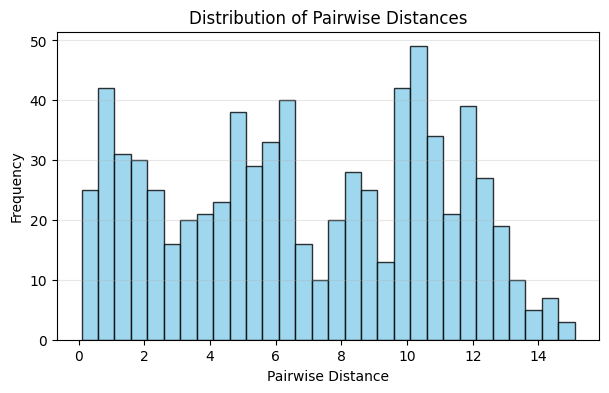

Distance statistics:
Min: 0.090
Max: 15.104
Mean: 6.898
Median: 6.569
Std: 3.994


In [51]:
# Flatten the upper triangle of the distance matrix (excluding diagonal)
triu_indices = np.triu_indices_from(dist_matrix, k=1)
distances = dist_matrix[triu_indices]

plt.figure(figsize=(7,4))
plt.hist(distances, bins=30, color='skyblue', edgecolor='k', alpha=0.8)
plt.xlabel('Pairwise Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Pairwise Distances')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Print summary statistics
print('Distance statistics:')
print(f'Min: {distances.min():.3f}')
print(f'Max: {distances.max():.3f}')
print(f'Mean: {distances.mean():.3f}')
print(f'Median: {np.median(distances):.3f}')
print(f'Std: {distances.std():.3f}')

In [49]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import numpy as np

# Assume x, y, weights, coords, dist_matrix, cost_matrix, etc. are already defined as in your greedy path code

# --- Run the greedy algorithm and record steps ---
n_points = len(coords)
visited = np.zeros(n_points, dtype=bool)
path = []
frames = []

current = np.argmax(weights)
path.append(current)
visited[current] = True
frames.append(list(path))  # Record initial state

while not np.all(visited):
    dists = dist_matrix[current]
    candidates = np.where((dists <= radius) & (~visited))[0]
    if len(candidates) == 0:
        candidates = np.where(~visited)[0]
        if len(candidates) == 0:
            break
    costs = cost_matrix[current, candidates]
    next_idx = candidates[np.argmin(costs)]
    path.append(next_idx)
    visited[next_idx] = True
    current = next_idx
    frames.append(list(path))  # Record after each step

# --- Animation function ---
fig, ax = plt.subplots(figsize=(8,6))

def animate(i):
    ax.clear()
    ax.scatter(x, y, c=weights, cmap='Reds', edgecolor='k', s=60, label='Points')
    # Plot all possible edges in light gray
    for m in range(n_points):
        for n in range(m+1, n_points):
            ax.plot([coords[m,0], coords[n,0]], [coords[m,1], coords[n,1]], color='lightgray', lw=0.5, alpha=0.2, zorder=0)
    # Plot path so far
    step_path = frames[i]
    step_coords = coords[step_path]
    ax.plot(step_coords[:,0], step_coords[:,1], color='blue', lw=2, label='Greedy Path', zorder=2)
    ax.scatter(x[step_path[0]], y[step_path[0]], c='lime', s=80, label='Start (Max Weight)')
    ax.scatter(x[step_path[-1]], y[step_path[-1]], c='cyan', s=80, label='Current')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(f'Greedy Path Construction Step {i+1}/{len(frames)}')
    ax.legend(loc='best')

# --- Create and save animation as GIF ---
anim = FuncAnimation(fig, animate, frames=len(frames), interval=800, repeat=False)
anim.save('greedy_path_animation.gif', writer=PillowWriter(fps=1))
plt.close(fig)

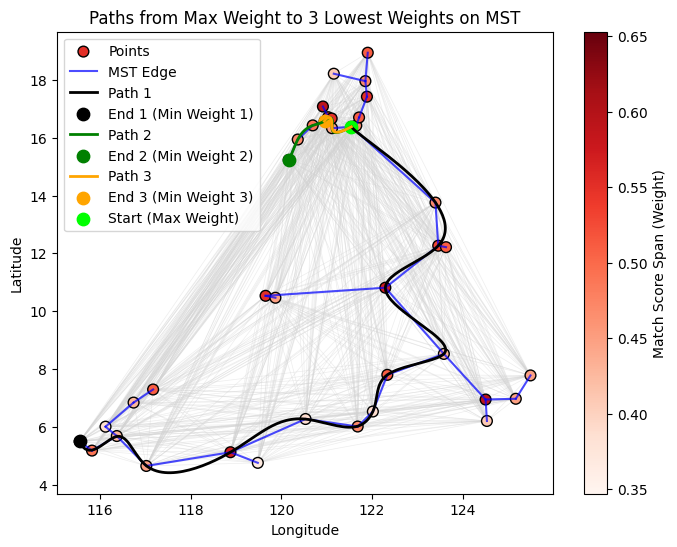

In [7]:
x = point_df_GA['longitude'].values
y = point_df_GA['latitude'].values
weights = point_df_GA['match_score_span'].values
coords = np.column_stack((x, y))

# -----------------------------
# 1. Build Weighted Graph
# -----------------------------
dist_matrix = cdist(coords, coords)
weight_matrix = (weights[:,None] + weights[None,:]) / 2
cost_matrix = dist_matrix / (weight_matrix + 1e-6)  # avoid div0

G = nx.Graph()
for i in range(len(coords)):
    for j in range(i+1, len(coords)):
        G.add_edge(i, j, weight=cost_matrix[i,j])

# -----------------------------
# 2. Minimum Spanning Tree
# -----------------------------
mst = nx.minimum_spanning_tree(G)

# Determine start (max weight) and end (min weight)
start = np.argmax(weights)
# Get indices of the 3 smallest weights (excluding the max)
end_candidates = np.argsort(weights)
ends = [end_candidates[0], end_candidates[1], end_candidates[2]]

colors = ['black', 'green', 'orange', 'purple', 'magenta']

plt.figure(figsize=(8,6))
sc = plt.scatter(x, y, c=weights, cmap='Reds', edgecolor='k', s=60, label='Points')

# Add colorbar for point values
cbar = plt.colorbar(sc)
cbar.set_label('Match Score Span (Weight)')

# Plot all possible edges in light gray
for i in range(len(coords)):
    for j in range(i+1, len(coords)):
        plt.plot([coords[i,0], coords[j,0]], [coords[i,1], coords[j,1]], color='lightgray', lw=0.5, alpha=0.4, zorder=0)

# Plot MST edges in blue
for idx, (u, v) in enumerate(mst.edges()):
    plt.plot([coords[u,0], coords[v,0]], [coords[u,1], coords[v,1]],
             color='blue', lw=1.5, alpha=0.7, zorder=1, label='MST Edge' if idx == 0 else "")

# Plot paths from max weight to each of the 3 lowest weights
for idx, end in enumerate(ends):
    if start == end:
        continue  # skip if start and end are the same
    path_nodes = nx.shortest_path(mst, source=start, target=end, weight='weight')
    path_coords = coords[path_nodes]
    if len(path_coords) > 3:
        tck, u = splprep([path_coords[:,0], path_coords[:,1]], s=0.001)
        u_fine = np.linspace(0,1,300)
        smooth_path = np.array(splev(u_fine, tck)).T
        plt.plot(smooth_path[:,0], smooth_path[:,1], color=colors[idx%len(colors)], lw=2, label=f'Path {idx+1}', zorder=3)
    else:
        plt.plot(path_coords[:,0], path_coords[:,1], color=colors[idx%len(colors)], lw=2, label=f'Path {idx+1}', zorder=3)
    plt.scatter(x[end], y[end], c=colors[idx%len(colors)], s=80, label=f'End {idx+1} (Min Weight {idx+1})')

plt.scatter(x[start], y[start], c='lime', s=80, label='Start (Max Weight)')

plt.legend(loc='best')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Paths from Max Weight to 3 Lowest Weights on MST')
plt.show()

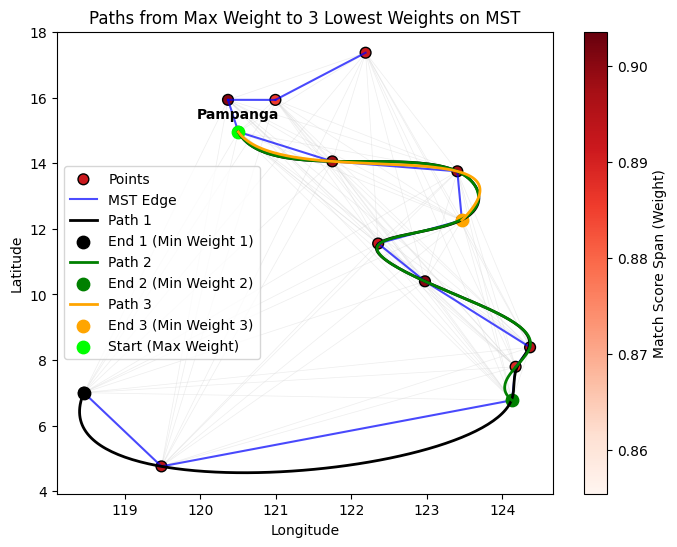

In [38]:
x = point_df_PA['longitude'].values
y = point_df_PA['latitude'].values
weights = point_df_PA['match_score_span'].values
coords = np.column_stack((x, y))

# -----------------------------
# 1. Build Weighted Graph
# -----------------------------
dist_matrix = cdist(coords, coords)
weight_matrix = (weights[:,None] + weights[None,:]) / 2
cost_matrix = dist_matrix / (weight_matrix + 1e-6)  # avoid div0

G = nx.Graph()
for i in range(len(coords)):
    for j in range(i+1, len(coords)):
        G.add_edge(i, j, weight=cost_matrix[i,j])

# -----------------------------
# 2. Minimum Spanning Tree
# -----------------------------
mst = nx.minimum_spanning_tree(G)

# Determine start (max weight) and end (min weight)
start = np.argmax(weights)
# Get indices of the 3 smallest weights (excluding the max)
end_candidates = np.argsort(weights)
ends = [end_candidates[0], end_candidates[1], end_candidates[2]]

colors = ['black', 'green', 'orange', 'purple', 'magenta']

plt.figure(figsize=(8,6))
sc = plt.scatter(x, y, c=weights, cmap='Reds', edgecolor='k', s=60, label='Points')

# Add colorbar for point values
cbar = plt.colorbar(sc)
cbar.set_label('Match Score Span (Weight)')

# Plot all possible edges in light gray
for i in range(len(coords)):
    for j in range(i+1, len(coords)):
        plt.plot([coords[i,0], coords[j,0]], [coords[i,1], coords[j,1]], color='lightgray', lw=0.5, alpha=0.4, zorder=0)

# Plot MST edges in blue
for idx, (u, v) in enumerate(mst.edges()):
    plt.plot([coords[u,0], coords[v,0]], [coords[u,1], coords[v,1]],
             color='blue', lw=1.5, alpha=0.7, zorder=1, label='MST Edge' if idx == 0 else "")

# Plot paths from max weight to each of the 3 lowest weights
for idx, end in enumerate(ends):
    if start == end:
        continue  # skip if start and end are the same
    path_nodes = nx.shortest_path(mst, source=start, target=end, weight='weight')
    path_coords = coords[path_nodes]
    if len(path_coords) > 3:
        tck, u = splprep([path_coords[:,0], path_coords[:,1]], s=0.001)
        u_fine = np.linspace(0,1,300)
        smooth_path = np.array(splev(u_fine, tck)).T
        plt.plot(smooth_path[:,0], smooth_path[:,1], color=colors[idx%len(colors)], lw=2, label=f'Path {idx+1}', zorder=3)
    else:
        plt.plot(path_coords[:,0], path_coords[:,1], color=colors[idx%len(colors)], lw=2, label=f'Path {idx+1}', zorder=3)
    plt.scatter(x[end], y[end], c=colors[idx%len(colors)], s=80, label=f'End {idx+1} (Min Weight {idx+1})')

plt.scatter(x[start], y[start], c='lime', s=80, label='Start (Max Weight)')

plt.annotate(
    point_df_PA['language'].iloc[start],
    (x[start], y[start]),
    textcoords="offset points",
    xytext=(0,10),
    ha='center',
    fontsize=10,
    color='black',
    weight='bold'
)

plt.legend(loc='best')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Paths from Max Weight to 3 Lowest Weights on MST')
plt.show()

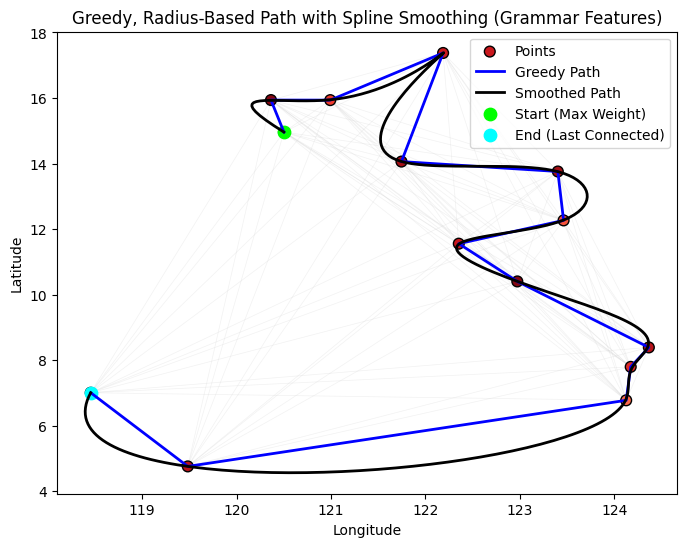

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from scipy.interpolate import splprep, splev

# --- Parameters ---
radius = 2.0

# --- Data ---
x = point_df_PA['longitude'].values
y = point_df_PA['latitude'].values
weights = point_df_PA['match_score_span'].values
coords = np.column_stack((x, y))

# --- Cost Matrix ---
dist_matrix = cdist(coords, coords)
weight_matrix = (weights[:, None] + weights[None, :]) / 2
alpha = 2  # Increase to make weights more influential
cost_matrix = dist_matrix / (weight_matrix ** alpha + 1e-6)

# --- Greedy Path Construction ---
n_points = len(coords)
visited = np.zeros(n_points, dtype=bool)
path = []

# Start at max weight
current = np.argmax(weights)
path.append(current)
visited[current] = True

while not np.all(visited):
    # Find unvisited neighbors within radius
    dists = dist_matrix[current]
    candidates = np.where((dists <= radius) & (~visited))[0]
    if len(candidates) == 0:
        # If no unvisited neighbors in radius, expand search to all unvisited
        candidates = np.where(~visited)[0]
        if len(candidates) == 0:
            break
    # Choose the candidate with minimum cost
    costs = cost_matrix[current, candidates]
    next_idx = candidates[np.argmin(costs)]
    path.append(next_idx)
    visited[next_idx] = True
    current = next_idx

path_coords = coords[path]

# --- Spline Smoothing ---
if len(path_coords) > 3:
    tck, u = splprep([path_coords[:,0], path_coords[:,1]], s=0.001)
    u_fine = np.linspace(0,1,300)
    smooth_path = np.array(splev(u_fine, tck)).T
else:
    smooth_path = path_coords

# --- Visualization ---
plt.figure(figsize=(8,6))
plt.scatter(x, y, c=weights, cmap='Reds', edgecolor='k', s=60, label='Points')

# Plot all possible edges in light gray
for i in range(n_points):
    for j in range(i+1, n_points):
        plt.plot([coords[i,0], coords[j,0]], [coords[i,1], coords[j,1]], color='lightgray', lw=0.5, alpha=0.3, zorder=0)

# Plot greedy path
plt.plot(path_coords[:,0], path_coords[:,1], color='blue', lw=2, label='Greedy Path', zorder=2)
plt.plot(smooth_path[:,0], smooth_path[:,1], color='black', lw=2, label='Smoothed Path', zorder=3)

# Mark start and end
plt.scatter(x[path[0]], y[path[0]], c='lime', s=80, label='Start (Max Weight)')
plt.scatter(x[path[-1]], y[path[-1]], c='cyan', s=80, label='End (Last Connected)')

plt.legend()
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Greedy, Radius-Based Path with Spline Smoothing (Grammar Features)')
plt.show()

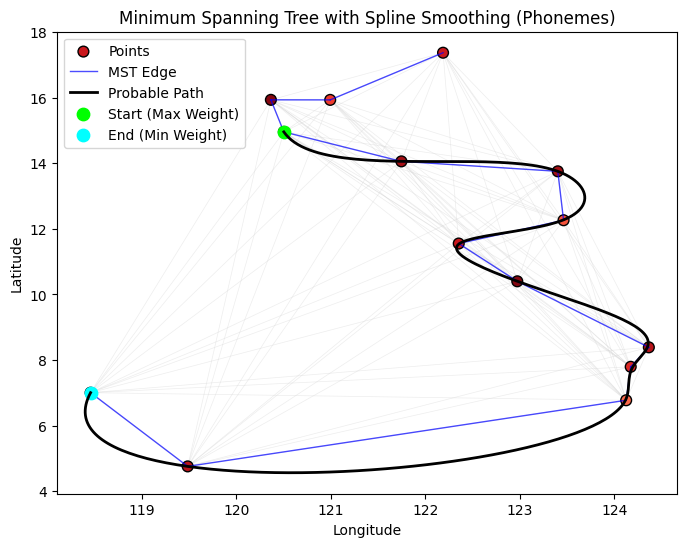

In [ ]:
x = point_df_PA['longitude'].values
y = point_df_PA['latitude'].values
weights = point_df_PA['match_score_span'].values
coords = np.column_stack((x, y))

# -----------------------------
# 1. Build Weighted Graph
# -----------------------------
# Edge cost = distance / combined weight
dist_matrix = cdist(coords, coords)
weight_matrix = (weights[:,None] + weights[None,:]) / 2
cost_matrix = dist_matrix / (weight_matrix + 1e-6)  # avoid div0

G = nx.Graph()
for i in range(len(coords)):
    for j in range(i+1, len(coords)):
        G.add_edge(i, j, weight=cost_matrix[i,j])

# -----------------------------
# 2. Minimum Spanning Tree
# -----------------------------
mst = nx.minimum_spanning_tree(G)

# Determine start (max weight) and end (min weight)
start = np.argmax(weights)
end = np.argmin(weights)

# Compute path along MST
path_nodes = nx.shortest_path(mst, source=start, target=end, weight='weight')
path_coords = coords[path_nodes]

# -----------------------------
# 3. Smooth Path with Spline
# -----------------------------
tck, u = splprep([path_coords[:,0], path_coords[:,1]], s=0.001)
u_fine = np.linspace(0,1,300)
smooth_path = np.array(splev(u_fine, tck)).T

# -----------------------------
# 4. Visualization
# -----------------------------
plt.figure(figsize=(8,6))
plt.scatter(x, y, c=weights, cmap='Reds', edgecolor='k', s=60, label='Points')

for i in range(len(coords)):
    for j in range(i+1, len(coords)):
        plt.plot([coords[i,0], coords[j,0]], [coords[i,1], coords[j,1]], color='lightgray', lw=0.5, alpha=0.4, zorder=0)

for u, v in mst.edges():
    plt.plot([coords[u,0], coords[v,0]], [coords[u,1], coords[v,1]], color='blue', lw=1, alpha=0.7, zorder=1, label='MST Edge' if u == list(mst.edges())[0][0] and v == list(mst.edges())[0][1] else "")

    
plt.plot(smooth_path[:,0], smooth_path[:,1], 'black', lw=2, label='Probable Path')
plt.scatter(x[start], y[start], c='lime', s=80, label='Start (Max Weight)')
plt.scatter(x[end], y[end], c='cyan', s=80, label='End (Min Weight)')
plt.legend()
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Minimum Spanning Tree with Spline Smoothing (Phonemes)')
plt.show()

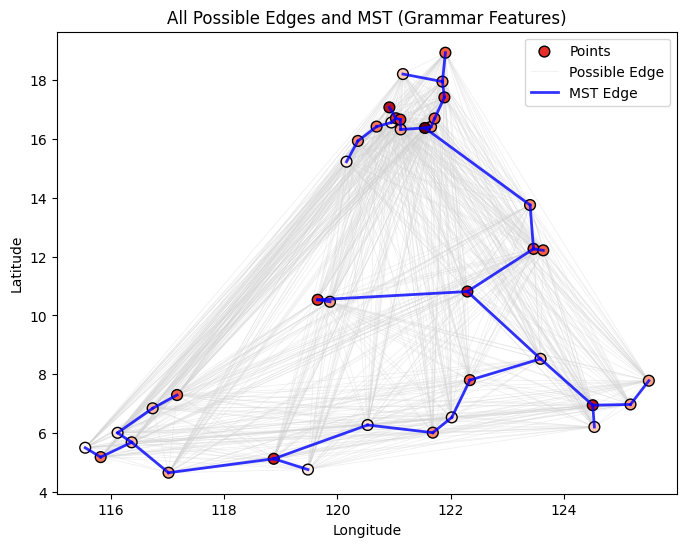

In [44]:
#Plot all possible edges and the MST for point_df_PA

x = point_df['longitude'].values
y = point_df['latitude'].values
weights = point_df['match_score_span'].values
coords = np.column_stack((x, y))

# Build weighted graph
dist_matrix = cdist(coords, coords)
weight_matrix = (weights[:, None] + weights[None, :]) / 2
cost_matrix = dist_matrix / (weight_matrix + 1e-6)

G = nx.Graph()
for i in range(len(coords)):
    for j in range(i+1, len(coords)):
        G.add_edge(i, j, weight=cost_matrix[i, j])

# MST
mst = nx.minimum_spanning_tree(G)

plt.figure(figsize=(8, 6))
plt.scatter(x, y, c=weights, cmap='Reds', edgecolor='k', s=60, label='Points')

# Plot all possible edges in light gray
for i in range(len(coords)):
    for j in range(i+1, len(coords)):
        plt.plot([coords[i, 0], coords[j, 0]], [coords[i, 1], coords[j, 1]],
                 color='lightgray', lw=0.5, alpha=0.4, zorder=0,label = 'Possible Edge' if i == 0 and j == 1 else "")

# Plot MST edges in blue
for idx, (u, v) in enumerate(mst.edges()):
    plt.plot([coords[u, 0], coords[v, 0]], [coords[u, 1], coords[v, 1]],
             color='blue', lw=2, alpha=0.8, zorder=1, label='MST Edge' if idx == 0 else "")

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('All Possible Edges and MST (Grammar Features)')
plt.legend()
plt.show()

In [ ]:
x = point_df['longitude'].values
y = point_df['latitude'].values
weights = point_df['match_score_span'].values
coords = np.column_stack((x, y))

# Build weighted graph
dist_matrix = cdist(coords, coords)
weight_matrix = (weights[:, None] + weights[None, :]) / 2
cost_matrix = dist_matrix / (weight_matrix + 1e-6)

G = nx.Graph()
for i in range(len(coords)):
    for j in range(i+1, len(coords)):
        G.add_edge(i, j, weight=cost_matrix[i, j])

# MST
mst = nx.minimum_spanning_tree(G)

# Start/end points
start = np.argmax(weights)
end = np.argmin(weights)

# Shortest path on MST
path_nodes = nx.shortest_path(mst, source=start, target=end, weight='weight')
path_coords = coords[path_nodes]

# Smooth path spline
if len(path_coords) <= 3:
    smooth_path = path_coords
else:
    tck, u = splprep([path_coords[:, 0], path_coords[:, 1]], s=0.001)
    u_fine = np.linspace(0, 1, 300)
    smooth_path = np.array(splev(u_fine, tck)).T

# Export MST edges as CSV
edges_data = []
for u, v in mst.edges():
    edges_data.append({
        'x_start': coords[u, 0], 'y_start': coords[u, 1],
        'x_end': coords[v, 0], 'y_end': coords[v, 1]
    })

edges_df = pd.DataFrame(edges_data)
edges_df.to_csv('mst_edges_GA.csv', index=False)

# Export smooth path as CSV
smooth_df = pd.DataFrame(smooth_path, columns=['x', 'y'])
smooth_df.to_csv('smooth_path_GA.csv', index=False)

In [40]:
x = point_df_PA['longitude'].values
y = point_df_PA['latitude'].values
weights = point_df_PA['match_score_span'].values
coords = np.column_stack((x, y))

# Build weighted graph
dist_matrix = cdist(coords, coords)
weight_matrix = (weights[:, None] + weights[None, :]) / 2
cost_matrix = dist_matrix / (weight_matrix + 1e-6)

G = nx.Graph()
for i in range(len(coords)):
    for j in range(i+1, len(coords)):
        G.add_edge(i, j, weight=cost_matrix[i, j])

# MST
mst = nx.minimum_spanning_tree(G)

# Start/end points
start = np.argmax(weights)
end = np.argmin(weights)

# Shortest path on MST
path_nodes = nx.shortest_path(mst, source=start, target=end, weight='weight')
path_coords = coords[path_nodes]

# Smooth path spline
if len(path_coords) <= 3:
    smooth_path = path_coords
else:
    tck, u = splprep([path_coords[:, 0], path_coords[:, 1]], s=0.001)
    u_fine = np.linspace(0, 1, 300)
    smooth_path = np.array(splev(u_fine, tck)).T

# Export MST edges as CSV
edges_data = []
for u, v in mst.edges():
    edges_data.append({
        'x_start': coords[u, 0], 'y_start': coords[u, 1],
        'x_end': coords[v, 0], 'y_end': coords[v, 1]
    })

edges_df = pd.DataFrame(edges_data)
edges_df.to_csv('mst_edges_PA.csv', index=False)

# Export smooth path as CSV
smooth_df = pd.DataFrame(smooth_path, columns=['x', 'y'])
smooth_df.to_csv('smooth_path_PA.csv', index=False)

# Nullified Weights
### Phoneme and Grammar Analysis

In [16]:
point_df_GA_null = point_df_GA.copy()
point_df_GA_null['match_score_span'] = 0
point_df_PA_null = point_df_PA.copy()
point_df_PA_null['match_score_span'] = 0

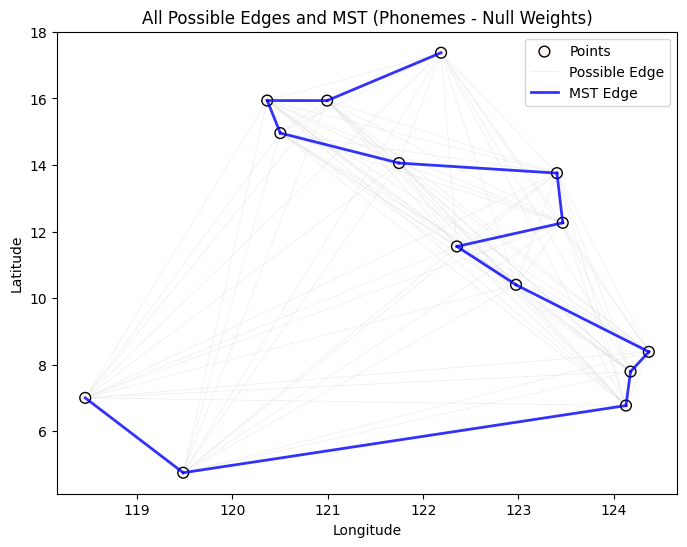

In [18]:
# Plot all possible edges and the MST for point_df_PA_null

x = point_df_PA_null['longitude'].values
y = point_df_PA_null['latitude'].values
weights = point_df_PA_null['match_score_span'].values
coords = np.column_stack((x, y))

# Build weighted graph
dist_matrix = cdist(coords, coords)
weight_matrix = (weights[:, None] + weights[None, :]) / 2
cost_matrix = dist_matrix / (weight_matrix + 1e-6)

G = nx.Graph()
for i in range(len(coords)):
    for j in range(i+1, len(coords)):
        G.add_edge(i, j, weight=cost_matrix[i, j])

# MST
mst = nx.minimum_spanning_tree(G)

plt.figure(figsize=(8, 6))
plt.scatter(x, y, c=weights, cmap='Reds', edgecolor='k', s=60, label='Points')

# Plot all possible edges in light gray
for i in range(len(coords)):
    for j in range(i+1, len(coords)):
        plt.plot([coords[i, 0], coords[j, 0]], [coords[i, 1], coords[j, 1]],
                 color='lightgray', lw=0.5, alpha=0.4, zorder=0,label = 'Possible Edge' if i == 0 and j == 1 else "")

# Plot MST edges in blue
for idx, (u, v) in enumerate(mst.edges()):
    plt.plot([coords[u, 0], coords[v, 0]], [coords[u, 1], coords[v, 1]],
             color='blue', lw=2, alpha=0.8, zorder=1, label='MST Edge' if idx == 0 else "")

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('All Possible Edges and MST (Phonemes - Null Weights)')
plt.legend()
plt.show()

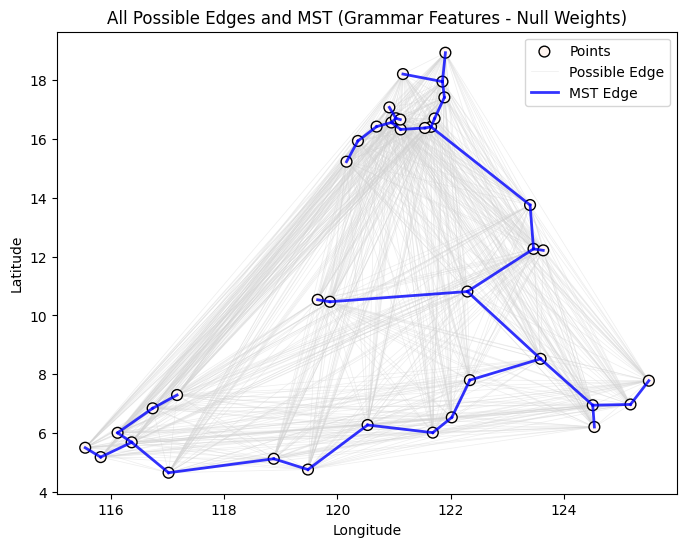

In [19]:
# Plot all possible edges and the MST for point_df_GA_null

x = point_df_GA_null['longitude'].values
y = point_df_GA_null['latitude'].values
weights = point_df_GA_null['match_score_span'].values
coords = np.column_stack((x, y))

# Build weighted graph
dist_matrix = cdist(coords, coords)
weight_matrix = (weights[:, None] + weights[None, :]) / 2
cost_matrix = dist_matrix / (weight_matrix + 1e-6)

G = nx.Graph()
for i in range(len(coords)):
    for j in range(i+1, len(coords)):
        G.add_edge(i, j, weight=cost_matrix[i, j])

# MST
mst = nx.minimum_spanning_tree(G)

plt.figure(figsize=(8, 6))
plt.scatter(x, y, c=weights, cmap='Reds', edgecolor='k', s=60, label='Points')

# Plot all possible edges in light gray
for i in range(len(coords)):
    for j in range(i+1, len(coords)):
        plt.plot([coords[i, 0], coords[j, 0]], [coords[i, 1], coords[j, 1]],
                 color='lightgray', lw=0.5, alpha=0.4, zorder=0,label = 'Possible Edge' if i == 0 and j == 1 else "")

# Plot MST edges in blue
for idx, (u, v) in enumerate(mst.edges()):
    plt.plot([coords[u, 0], coords[v, 0]], [coords[u, 1], coords[v, 1]],
             color='blue', lw=2, alpha=0.8, zorder=1, label='MST Edge' if idx == 0 else "")

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('All Possible Edges and MST (Grammar Features - Null Weights)')
plt.legend()
plt.show()

# Shuffling Weights
### Phoneme and Grammar Analysis

In [56]:
point_df_GA_shuffled = point_df_GA.copy()
point_df_GA_shuffled['match_score_span'] = np.random.permutation(point_df_GA_shuffled['match_score_span'].values)
point_df_PA_shuffled = point_df_PA.copy()
point_df_PA_shuffled['match_score_span'] = np.random.permutation(point_df_PA_shuffled['match_score_span'].values)

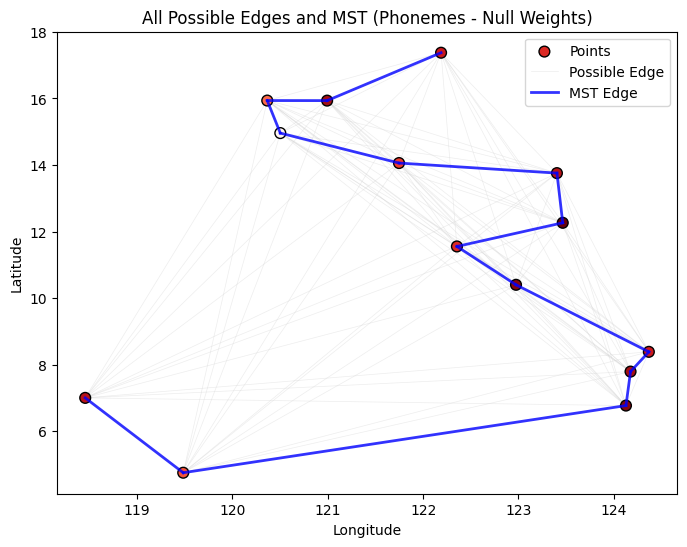

In [ ]:
# Plot all possible edges and the MST for point_df_PA_shuffled

x = point_df_PA_shuffled['longitude'].values
y = point_df_PA_shuffled['latitude'].values
weights = point_df_PA_shuffled['match_score_span'].values
coords = np.column_stack((x, y))

# Build weighted graph
dist_matrix = cdist(coords, coords)
weight_matrix = (weights[:, None] + weights[None, :]) / 2
alpha = 2  # or higher
cost_matrix = dist_matrix / (weight_matrix**alpha + 1e-6)

G = nx.Graph()
for i in range(len(coords)):
    for j in range(i+1, len(coords)):
        G.add_edge(i, j, weight=cost_matrix[i, j])

# MST
mst = nx.minimum_spanning_tree(G)

plt.figure(figsize=(8, 6))
plt.scatter(x, y, c=weights, cmap='Reds', edgecolor='k', s=60, label='Points')

# Plot all possible edges in light gray
for i in range(len(coords)):
    for j in range(i+1, len(coords)):
        plt.plot([coords[i, 0], coords[j, 0]], [coords[i, 1], coords[j, 1]],
                 color='lightgray', lw=0.5, alpha=0.4, zorder=0,label = 'Possible Edge' if i == 0 and j == 1 else "")

# Plot MST edges in blue
for idx, (u, v) in enumerate(mst.edges()):
    plt.plot([coords[u, 0], coords[v, 0]], [coords[u, 1], coords[v, 1]],
             color='blue', lw=2, alpha=0.8, zorder=1, label='MST Edge' if idx == 0 else "")

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('All Possible Edges and MST (Phonemes - Shuffled Weights)')
plt.legend()
plt.show()

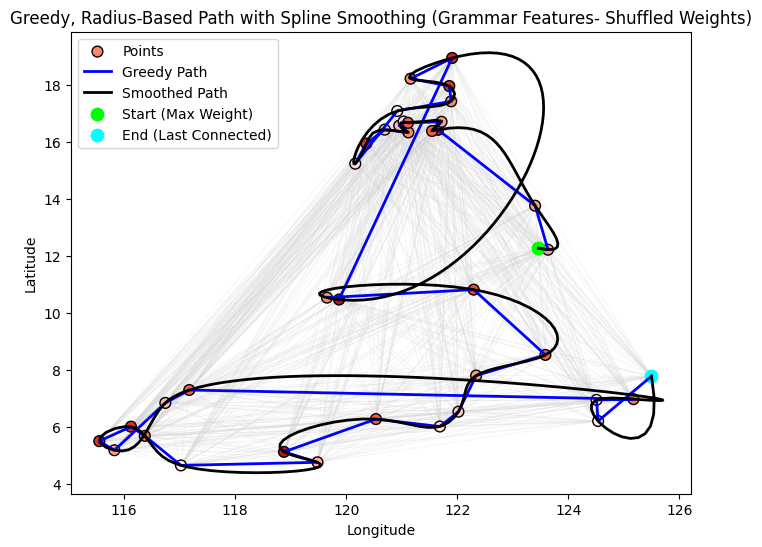

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from scipy.interpolate import splprep, splev

# --- Parameters ---
radius = 3

# --- Data ---
x = point_df_GA_shuffled['longitude'].values
y = point_df_GA_shuffled['latitude'].values
weights = point_df_GA_shuffled['match_score_span'].values
coords = np.column_stack((x, y))

# --- Cost Matrix ---
dist_matrix = cdist(coords, coords)
weight_matrix = (weights[:, None] + weights[None, :]) / 2
alpha = 2  # Increase to make weights more influential
cost_matrix = dist_matrix / (weight_matrix ** alpha + 1e-6)

# --- Greedy Path Construction ---
n_points = len(coords)
visited = np.zeros(n_points, dtype=bool)
path = []

# Start at max weight
current = np.argmax(weights)
path.append(current)
visited[current] = True

while not np.all(visited):
    # Find unvisited neighbors within radius
    dists = dist_matrix[current]
    candidates = np.where((dists <= radius) & (~visited))[0]
    if len(candidates) == 0:
        # If no unvisited neighbors in radius, expand search to all unvisited
        candidates = np.where(~visited)[0]
        if len(candidates) == 0:
            break
    # Choose the candidate with minimum cost
    costs = cost_matrix[current, candidates]
    next_idx = candidates[np.argmin(costs)]
    path.append(next_idx)
    visited[next_idx] = True
    current = next_idx

path_coords = coords[path]

# --- Spline Smoothing ---
if len(path_coords) > 3:
    tck, u = splprep([path_coords[:,0], path_coords[:,1]], s=0.001)
    u_fine = np.linspace(0,1,300)
    smooth_path = np.array(splev(u_fine, tck)).T
else:
    smooth_path = path_coords

# --- Visualization ---
plt.figure(figsize=(8,6))
plt.scatter(x, y, c=weights, cmap='Reds', edgecolor='k', s=60, label='Points')

# Plot all possible edges in light gray
for i in range(n_points):
    for j in range(i+1, n_points):
        plt.plot([coords[i,0], coords[j,0]], [coords[i,1], coords[j,1]], color='lightgray', lw=0.5, alpha=0.3, zorder=0)

# Plot greedy path
plt.plot(path_coords[:,0], path_coords[:,1], color='blue', lw=2, label='Greedy Path', zorder=2)
plt.plot(smooth_path[:,0], smooth_path[:,1], color='black', lw=2, label='Smoothed Path', zorder=3)

# Mark start and end
plt.scatter(x[path[0]], y[path[0]], c='lime', s=80, label='Start (Max Weight)')
plt.scatter(x[path[-1]], y[path[-1]], c='cyan', s=80, label='End (Last Connected)')

plt.legend()
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Greedy, Radius-Based Path with Spline Smoothing (Grammar Features- Shuffled Weights)')
plt.show()